*Identify any column of your dataset having missing numerical values more than 20 percent and compare the before and after removal of the rows.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Building_Permits.csv")

C:\Users\User\AppData\Local\Temp\ipykernel_13976\1014540178.py:1: DtypeWarning: Columns (0: Voluntary Soft-Story Retrofit, 1: TIDF Compliance) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Building_Permits.csv")


In [3]:
df.sample(5)

,Permit Number,Permit Type,Permit Type Definition,Permit Creation Date,Block,Lot,Street Number,Street Number Suffix,Street Name,Street Suffix,...,Existing Construction Type,Existing Construction Type Description,Proposed Construction Type,Proposed Construction Type Description,Site Permit,Supervisor District,Neighborhoods - Analysis Boundaries,Zipcode,Location,Record ID
28867,201307172063,8,otc alterations permit,07/17/2013,0842,063,570,NaN,Page,St,...,5.0,wood frame (5),5.0,wood frame (5),NaN,5.0,Hayes Valley,94117.0,"(37.7734097970067, -122.43015452299369)",1321837479040
66979,201411071028,8,otc alterations permit,11/07/2014,0311,015,1,NaN,Post,St,...,5.0,wood frame (5),5.0,wood frame (5),NaN,3.0,Financial District/South Beach,94104.0,"(37.78873939880986, -122.40250914685684)",1361747305172
120085,M679530,8,otc alterations permit,04/06/2016,0500,004,2621,NaN,Larkin,St,...,NaN,NaN,NaN,NaN,NaN,2.0,Russian Hill,94109.0,"(37.802053715768494, -122.42158928147362)",141872272055
160411,201706300774,8,otc alterations permit,06/30/2017,0813,007,1390,NaN,Market,St,...,2.0,constr type 2,2.0,constr type 2,NaN,6.0,Tenderloin,94102.0,"(37.77714337988543, -122.41722981059696)",1468915469167
28857,M437767,8,otc alterations permit,10/23/2013,3558,075,3448,NaN,16th,St,...,NaN,NaN,NaN,NaN,NaN,8.0,Castro/Upper Market,94114.0,"(37.764631382981456, -122.42964139243725)",1321827415349


In [ ]:
# Step 2: Select only numerical columns
numerical_columns = df.select_dtypes(include=['number']).columns

In [ ]:
missing_percentage = (df[numerical_columns].isnull().sum() / len(df)) * 100

In [19]:
# Find the Cloumn having more than 20% of missing Values

columns_above_20 = missing_percentage[missing_percentage > 20]

print(columns_above_20)

Unit                          85.178984
Number of Existing Stories    21.510307
Number of Proposed Stories    21.552539
Existing Units                25.911513
Proposed Units                25.596280
Existing Construction Type    21.802916
Proposed Construction Type    21.700352
dtype: float64


In [20]:
# Step 5: Select one column
selected_column = columns_above_20.index[3]

print(selected_column)

Existing Units


In [ ]:
# Step 6: Missing information before removal
missing_before = df[selected_column].isnull().sum()

missing_percent_before = (missing_before / len(df)) * 100

In [21]:
print("Dataset Shape:", df.shape)

print("Missing Values in", selected_column, ":",missing_before)

print("Missing Percentage:",missing_percent_before, "%")

Dataset Shape: (198900, 43)
Missing Values in Existing Units : 51538
Missing Percentage: 25.91151332327803 %


In [22]:
# Step 7: Remove rows having missing values in the selected column
df_after = df.dropna(subset=[selected_column])

In [23]:
# Step 8: Information after row removal
missing_after = df_after[selected_column].isnull().sum()

missing_percent_after = (missing_after / len(df_after)) * 100

print("Dataset Shape:", df_after.shape)

print("Missing Values in", selected_column, ":",missing_after)

print("Missing Percentage:",missing_percent_after, "%")

Dataset Shape: (147362, 43)
Missing Values in Existing Units : 0
Missing Percentage: 0.0 %


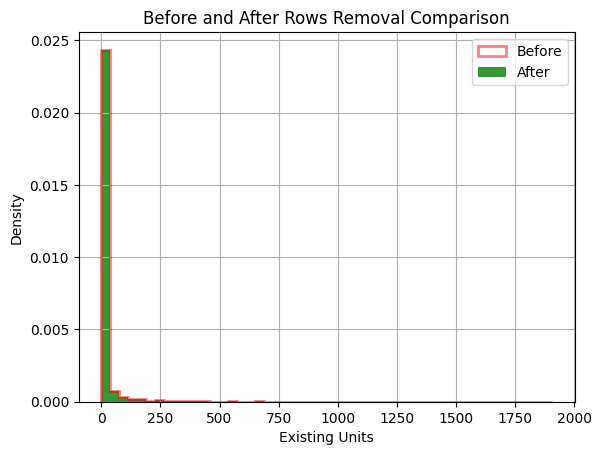

In [18]:
# Original data before removing rows
df[selected_column].hist(bins=50, density=True, color='red', label='Before', alpha=0.5, histtype='step', linewidth=2)

# Data after removing rows
df_after[selected_column].hist(bins=50, density=True, color='green', label='After', alpha=0.8)

# Graph details
plt.title("Before and After Rows Removal Comparison")
plt.xlabel(selected_column)
plt.ylabel("Density")
plt.legend()

plt.show()